In [2]:
import sqlite3

In [4]:
%whos

Variable   Type          Data/Info
----------------------------------
conn       Connection    <sqlite3.Connection object at 0x7f241ff2d040>
sqlite3    module        <module 'sqlite3' from '/<...>.10/sqlite3/__init__.py'>


In [5]:
import pandas as pd

In [7]:
import pandas as pd

df = pd.read_csv("/home/sankar/Documents/Flight-delay-prediction/data/cleaned_flights.csv")

In [8]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_HOUR,SCHEDULED_TIME,DISTANCE,IS_WEEKEND,DELAYED
0,2015,3,8,7,WN,MCI,MDW,1505,15,80.0,405,1,1
1,2015,5,3,7,WN,DAL,MCI,1735,17,85.0,460,1,0
2,2015,4,3,5,WN,RSW,CMH,1445,14,150.0,930,0,0
3,2015,3,28,6,OO,GTF,DEN,1458,14,114.0,624,1,1
4,2015,9,6,7,WN,ATL,MCO,1635,16,90.0,404,1,0


In [9]:
import pandas as pd
import sqlite3

df = pd.read_csv("../data/cleaned_flights.csv")

print(df.shape)

(499999, 13)


In [10]:
conn = sqlite3.connect("../data/flights.db")

df.to_sql(
    "flights",
    conn,
    if_exists="replace",
    index=False
)

499999

In [11]:
query = """
SELECT
    AIRLINE,
    COUNT(*) AS total_flights,
    ROUND(AVG(DELAYED) * 100, 2) AS delay_rate_percent
FROM flights
GROUP BY AIRLINE
ORDER BY delay_rate_percent DESC;
"""

airline_results = pd.read_sql_query(query, conn)

airline_results

,AIRLINE,total_flights,delay_rate_percent
0,NK,9983,27.31
1,UA,44484,24.13
2,F9,7734,22.45
3,B6,22908,21.66
4,WN,107987,21.10
5,MQ,24949,20.64
6,AA,59405,17.76
7,EV,49103,17.68
8,OO,50825,16.26
9,VX,5286,16.02


In [12]:
query = """
SELECT
    ORIGIN_AIRPORT,
    DESTINATION_AIRPORT,
    COUNT(*) AS total_flights,
    ROUND(AVG(DELAYED) * 100, 2) AS delay_rate_percent
FROM flights
GROUP BY ORIGIN_AIRPORT, DESTINATION_AIRPORT
HAVING COUNT(*) >= 500
ORDER BY delay_rate_percent DESC
LIMIT 15;
"""

route_results = pd.read_sql_query(query, conn)

route_results

,ORIGIN_AIRPORT,DESTINATION_AIRPORT,total_flights,delay_rate_percent
0,ORD,SFO,573,31.59
1,ORD,BOS,574,30.14
2,ORD,LAX,690,29.57
3,ORD,LGA,780,28.97
4,LAX,OAK,539,28.94
5,ORD,MSP,550,28.91
6,ORD,DCA,538,27.70
7,DFW,LAX,575,27.48
8,ORD,DFW,696,26.44
9,ORD,ATL,572,25.70


In [13]:
query = """
SELECT
    DEPARTURE_HOUR,
    COUNT(*) AS total_flights,
    ROUND(AVG(DELAYED) * 100, 2) AS delay_rate_percent
FROM flights
GROUP BY DEPARTURE_HOUR
ORDER BY DEPARTURE_HOUR;
"""

hour_results = pd.read_sql_query(query, conn)

hour_results

,DEPARTURE_HOUR,total_flights,delay_rate_percent
0,0,1211,15.94
1,1,427,18.50
2,2,138,11.59
3,3,59,15.25
4,4,40,27.50
5,5,9929,5.95
6,6,34931,6.54
7,7,33978,8.67
8,8,32793,10.62
9,9,30419,13.03


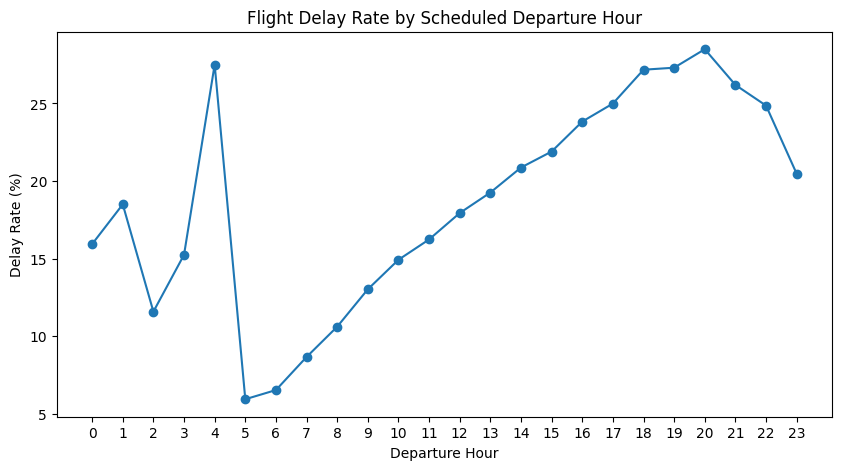

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    hour_results["DEPARTURE_HOUR"],
    hour_results["delay_rate_percent"],
    marker="o"
)

plt.title("Flight Delay Rate by Scheduled Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Delay Rate (%)")
plt.xticks(range(0, 24))

plt.show()

In [15]:
query = """
SELECT
    MONTH,
    COUNT(*) AS total_flights,
    ROUND(AVG(DELAYED) * 100, 2) AS delay_rate_percent
FROM flights
GROUP BY MONTH
ORDER BY MONTH;
"""

month_results = pd.read_sql_query(query, conn)

month_results

,MONTH,total_flights,delay_rate_percent
0,1,47307,19.61
1,2,42615,22.41
2,3,50434,19.62
3,4,48582,16.66
4,5,49709,18.26
5,6,50342,23.49
6,7,52042,21.24
7,8,51072,18.94
8,9,46523,12.72
9,10,48609,12.44


In [16]:
airline_results.to_csv(
    "../data/airline_delay_analysis.csv",
    index=False
)

route_results.to_csv(
    "../data/route_delay_analysis.csv",
    index=False
)

hour_results.to_csv(
    "../data/hour_delay_analysis.csv",
    index=False
)

month_results.to_csv(
    "../data/month_delay_analysis.csv",
    index=False
)